In [1]:
import kagglehub

# Fetch the depression dataset
path = kagglehub.dataset_download("arashnic/the-depression-dataset")

100%|██████████| 4.98M/4.98M [00:01<00:00, 3.13MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# Define absolute path from kagglehub cache
data_path = "/root/.cache/kagglehub/datasets/arashnic/the-depression-dataset/versions/1/data"

# Load first subject from both control and condition cohorts
control_df = pd.read_csv(f"{data_path}/control/control_1.csv")
condition_df = pd.read_csv(f"{data_path}/condition/condition_1.csv")

# Verify raw data structure
control_df.head()

,timestamp,date,activity
0,2003-03-18 15:00:00,2003-03-18,60
1,2003-03-18 15:01:00,2003-03-18,0
2,2003-03-18 15:02:00,2003-03-18,264
3,2003-03-18 15:03:00,2003-03-18,662
4,2003-03-18 15:04:00,2003-03-18,293


Extracted Circadian Features (Amplitude, Acrophase):
Control:  Amp = -75.40, Acro = 12.21
Patient:  Amp = -163.48, Acro = 14.52


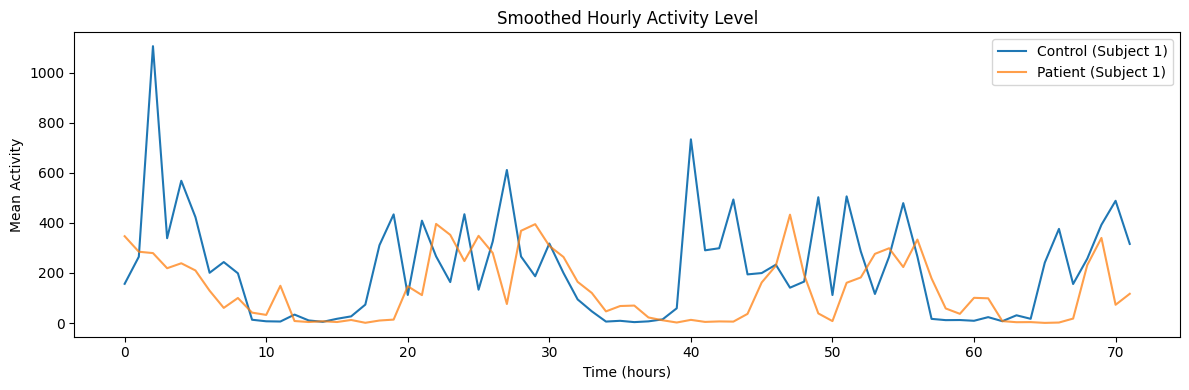

In [3]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Helper function to preprocess timeseries: convert to datetime and resample to hourly intervals
def prep_timeseries(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    hourly = df.set_index('timestamp')['activity'].resample('h').mean().reset_index()
    hourly = hourly.dropna()
    hourly['t'] = np.arange(len(hourly))
    return hourly

control_hourly = prep_timeseries(control_df)
condition_hourly = prep_timeseries(condition_df)

# Define standard Cosinor model for circadian rhythm extraction
# f(t) = Mesor + Amplitude * cos(2*pi*(t - Acrophase) / 24)
def cosinor(t, mesor, amp, acrophase):
    return mesor + amp * np.cos(2 * np.pi * (t - acrophase) / 24)

# Non-linear least squares fitting
# Initial guesses based on standard human activity (Mesor~200, Amp~100, Acro~14h)
p0 = [200, 100, 14]

popt_c, _ = curve_fit(cosinor, control_hourly['t'], control_hourly['activity'], p0=p0)
popt_p, _ = curve_fit(cosinor, condition_hourly['t'], condition_hourly['activity'], p0=p0)

print("Extracted Circadian Features (Amplitude, Acrophase):")
print(f"Control:  Amp = {popt_c[1]:.2f}, Acro = {popt_c[2]:.2f}")
print(f"Patient:  Amp = {popt_p[1]:.2f}, Acro = {popt_p[2]:.2f}")

# Visualize smoothed timeseries (First 72 hours)
plt.figure(figsize=(12, 4))
plt.plot(control_hourly['t'][:72], control_hourly['activity'][:72], label='Control (Subject 1)')
plt.plot(condition_hourly['t'][:72], condition_hourly['activity'][:72], label='Patient (Subject 1)', alpha=0.75)
plt.title("Smoothed Hourly Activity Level")
plt.xlabel("Time (hours)")
plt.ylabel("Mean Activity")
plt.legend()
plt.tight_layout()
plt.show()